In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [3]:
fraud_df.head()

fraud_df.shape

fraud_df.info()

fraud_df.describe()

fraud_df.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


,signup_time,purchase_time,device_id,source,browser,sex
count,151112,151112,151112,151112,151112,151112
unique,151112,150679,137956,3,5,2
top,2015-02-24 22:55:49,2015-06-08 09:42:04,CQTUVBYIWWWBC,SEO,Chrome,M
freq,1,3,20,60615,61432,88293


In [4]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [5]:
fraud_df.dtypes

user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object

In [6]:
fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

In [7]:
fraud_df["class"].value_counts()

fraud_df["class"].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

### Observation
The dataset is imbalanced, with approximately 90.6% legitimate transactions and 9.4% fraudulent transactions. This suggests that accuracy alone will not be an appropriate evaluation metric, and resampling techniques such as SMOTE may be required during model training.

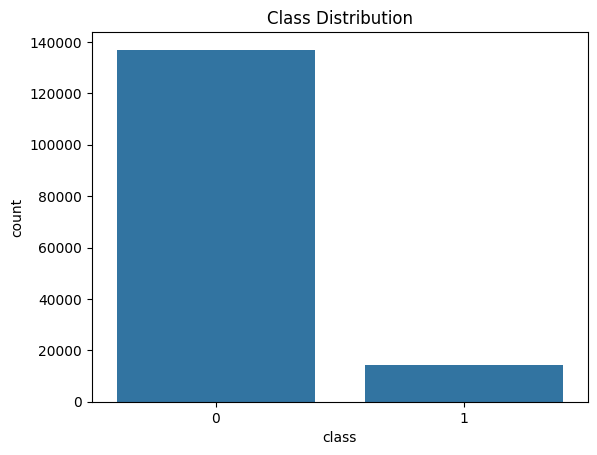

In [8]:
sns.countplot(x="class", data=fraud_df)
plt.title("Class Distribution")
plt.show()

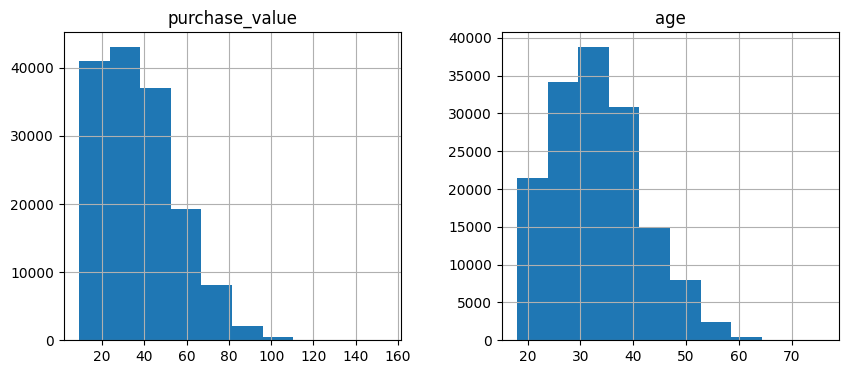

In [9]:
fraud_df[["purchase_value", "age"]].hist(
    figsize=(10, 4)
)

plt.show()

### Observation
The distribution of purchase values differs between legitimate and fraudulent transactions, suggesting that transaction amount may contribute to fraud prediction.
Age distributions between fraudulent and legitimate transactions show some overlap, although the feature may still provide incremental predictive value when combined with other variables.

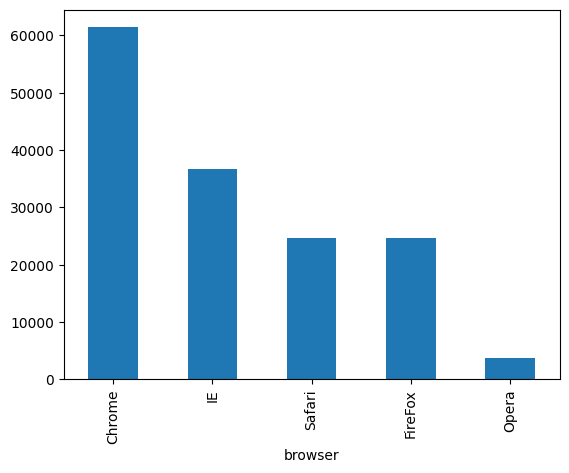

In [10]:
fraud_df["browser"].value_counts().plot(
    kind="bar"
)

plt.show()

### Observation
Fraud rates appear relatively similar across browsers, although Chrome users exhibit a slightly higher fraud rate compared to other browser categories.

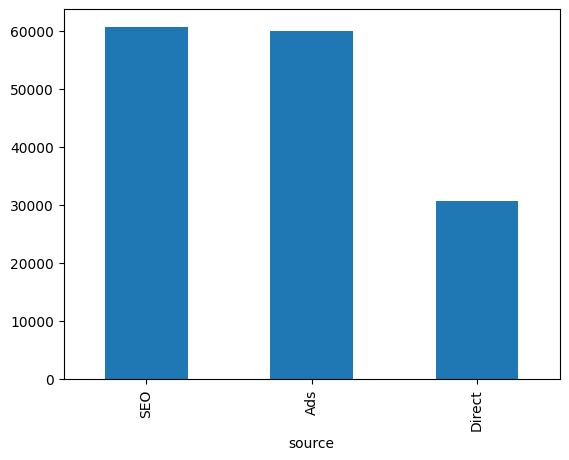

In [11]:
fraud_df["source"].value_counts().plot(
    kind="bar"
)

plt.show()

### Observation
Transactions originating from the Direct channel show the highest proportion of fraudulent activity, indicating that acquisition source may provide useful predictive information.

In [12]:
pd.crosstab(
    fraud_df["browser"],
    fraud_df["class"],
    normalize="index"
)

class,0,1
browser,,
Chrome,0.901208,0.098792
FireFox,0.904835,0.095165
IE,0.913225,0.086775
Opera,0.910773,0.089227
Safari,0.909799,0.090201


In [13]:
pd.crosstab(
    fraud_df["source"],
    fraud_df["class"],
    normalize="index"
)

class,0,1
source,,
Ads,0.907934,0.092066
Direct,0.894630,0.105370
SEO,0.910715,0.089285


In [14]:
fraud_df.duplicated().sum()

np.int64(0)

In [15]:
pd.crosstab(
    fraud_df["sex"],
    fraud_df["class"],
    normalize="index"
)

class,0,1
sex,,
F,0.908993,0.091007
M,0.904477,0.095523


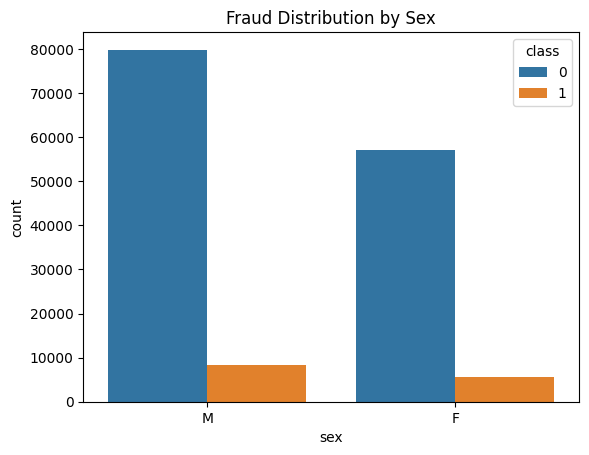

In [16]:
sns.countplot(
    x="sex",
    hue="class",
    data=fraud_df
)

plt.title("Fraud Distribution by Sex")
plt.show()

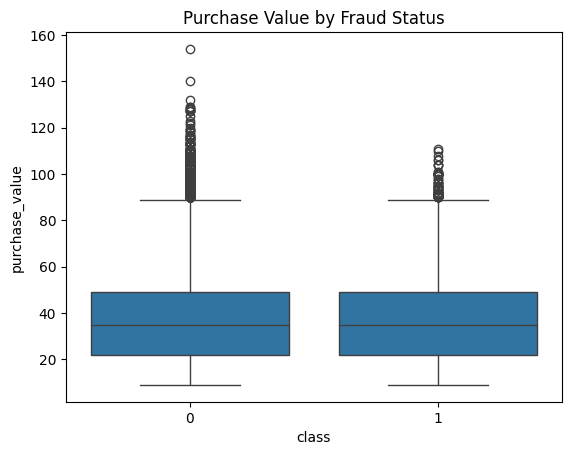

In [17]:
sns.boxplot(
    x="class",
    y="purchase_value",
    data=fraud_df
)

plt.title("Purchase Value by Fraud Status")
plt.show()

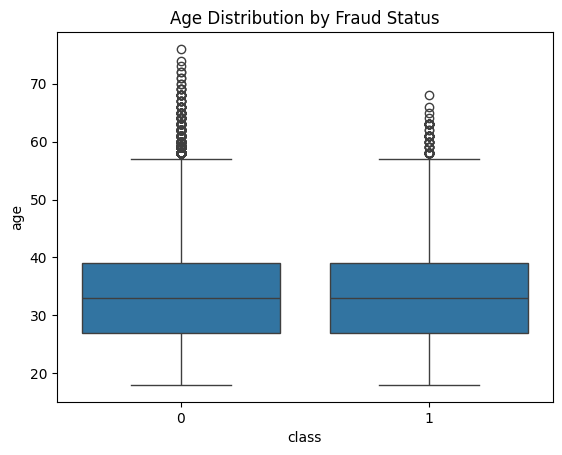

In [18]:
sns.boxplot(
    x="class",
    y="age",
    data=fraud_df
)

plt.title("Age Distribution by Fraud Status")
plt.show()

In [19]:
fraud_df.head()

fraud_df.shape

fraud_df.info()

fraud_df.describe()

fraud_df.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(4)
memory usage: 12.7+ MB


,device_id,source,browser,sex
count,151112,151112,151112,151112
unique,137956,3,5,2
top,CQTUVBYIWWWBC,SEO,Chrome,M
freq,20,60615,61432,88293


In [20]:
print("Shape:", fraud_df.shape)

fraud_df.info()

display(fraud_df.head())

display(fraud_df.describe())

display(fraud_df.describe(include="object"))

Shape: (151112, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(4)
memory usage: 12.7+ MB


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


,user_id,signup_time,purchase_time,purchase_value,age,ip_address,class
count,151112.000000,151112,151112,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,2015-04-20 00:56:09.511329280,2015-06-16 02:56:38.759952896,36.935372,33.140704,2.152145e+09,0.093646
min,2.000000,2015-01-01 00:00:42,2015-01-01 00:00:44,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,2015-02-18 09:52:48.500000,2015-04-18 14:41:25.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,2015-04-19 04:41:30,2015-06-18 13:46:17.500000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,2015-06-18 14:47:22.750000128,2015-08-17 18:48:31.500000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,2015-08-18 04:40:29,2015-12-16 02:56:05,154.000000,76.000000,4.294850e+09,1.000000
std,115369.285024,NaN,NaN,18.322762,8.617733,1.248497e+09,0.291336


,device_id,source,browser,sex
count,151112,151112,151112,151112
unique,137956,3,5,2
top,CQTUVBYIWWWBC,SEO,Chrome,M
freq,20,60615,61432,88293
